In [106]:
import IPython.display as ipd

import os, sys
current_path = os.getcwd()
path_parts = current_path.split(os.sep)
idx = path_parts.index("occupancy-estimation")
homepath = os.sep.join(path_parts[:idx + 1]) +"/"
sys.path.append(homepath)

import pandas as pd
import gemmi
import matplotlib.pyplot as plt
import meteor
import reciprocalspaceship as rs
from occupancy import *
from plotting3d import *
%load_ext autoreload 
%autoreload 2

from generate_objects import run_scaleit

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [107]:
from photolyase import *


In [108]:
folderloc =  homepath+'../photolyase_share_reviewers/'
dataloc_dark  = folderloc + '1_superdark/superdark_deposit.mtz'
pdbloc_dark  = folderloc + '1_superdark/superdark_deposit.pdb'
changing_bit = "6_10ns/10ns"
changing_bit = "7_30ns/30ns"
dataloc_light = folderloc + changing_bit + "_deposit.mtz"
pdbloc_light  = folderloc + changing_bit + '_deposit.pdb'

mask_loc_sphere = homepath+"../photolyase_masks/photolyase_TT_chainA_spherical_mask.ccp4"
mask_loc_handcraft = homepath+"../photolyase_masks/photolyase_chainA_spherical_masks.ccp4"
hs_limit = 1.2


# photolyase_hash = "photolyase10"
# parent=homepath
# pdb_pair = get_pdb_pairs(photolyase_hash)
# fname_dark = f"{parent}/synthetic_data/{pdb_pair[0]}.pdb"
# fname_mix = f"{parent}/synthetic_data/{pdb_pair[1]}.pdb"



In [109]:
!ls $folderloc

10_30us                        6_10ns
11_100us                       7_30ns
1_superdark                    8_1us
2_3ps                          9_10us
3_300ps                        low_pump_power_difference_maps
4_1ns                          readme.txt
5_3ns                          restraints


# Data Preparation

## Obtaining F and rho from real data

In [110]:
from photolyase import get_exp_structure_factors
from meteor.utils import cut_resolution
ds_light = rs.read_mtz(dataloc_light)
ds_dark = rs.read_mtz(dataloc_dark)

ds_dark = cut_resolution(ds_dark,high_resolution_limit=hs_limit)
ds_light = cut_resolution(ds_light,high_resolution_limit=hs_limit)



In [111]:
def get_model_densities(fname_dark, fname_mix, hs_limit):
    struc_dark = gemmi.read_structure(fname_dark)

In [112]:
from photolyase import k2real

f_dark, f_light = get_exp_structure_factors(ds_dark, ds_light)
f_angle = np.angle(f_dark)
rho_dark = k2real(f_dark)
rho_light = k2real(f_light)


Running scaleit, see tmp/launch_scaleit.sh


In [113]:
rho_light.shape

(180, 300, 432)

## Loading already phased result for RoI

In [114]:
from photolyase import get_model_densities

density_darkT, density_lightT = get_model_densities(pdbloc_dark, pdbloc_light, hs_limit)


# Creating Masks

## Calculating DoG Filter on real data

In [115]:
mask_names = [
    "dog_exp",
    "dog_dep",
    "pseudo-z",
    "ball",
    "handpicked",
    "nomask",
    ]
titles_mask = {
    "dog_exp":           "DoG (Measurement)", 
    "dog_dep":           "DoG (PDB deposited)",  
    "pseudo-z":          "largest and smallest values \n(0.01%) (PDB deposited)",
    "ball":               "Ball of Interest",
    "handpicked":         "Hand picked Mask",
    "nomask":         "No Mask",
}

masks = {}

## Extracting Regions of Interest from DoG

In [116]:
# setting parameters for DoG Filter

dark_struc = gemmi.read_structure(pdbloc_dark)

unit = np.array((
    dark_struc.cell.a,
    dark_struc.cell.b,
    dark_struc.cell.c
))


dark_struc.cell

step_size = np.array(rho_dark.shape)/ unit
print(step_size)
sigma = np.mean(step_size) * 1.75
thresh_pos = 0.35
thresh_neg = 0.5


[2.56410256 2.54755435 2.53417024]


In [117]:
sesh_name = "dog_exp"
if sesh_name in mask_names:
    nth_val = 40*2**3
    rho_shape = np.array(rho_light.shape)
    mask_pos_real, mask_neg_real, dog_filter_real = calculate_dog_filter_mask_v2(np.real(rho_light-rho_dark), 
                                                                                 sigma, thresh_pos, thresh_neg,
                                                                                 nth_val, rho_shape, detailed=True)
    mask_dog_real = mask_pos_real+mask_neg_real
    masks[sesh_name] = mask_dog_real

dogged
0.0 {0: 55296000}
-0.0 {0: 55296000}


In [118]:
sesh_name = "dog_dep"
if sesh_name in mask_names:
    rho_delta_xtr = density_lightT-density_darkT
    nth_val = 40*2**3
    mask_pos_xtr, mask_neg_xtr, dog_filter_xtr = calculate_dog_filter_mask_v2(rho_delta_xtr, sigma, thresh_pos, thresh_neg,
                                                                              nth_val, rho_shape, detailed=True)
    mask_dog_xtr = mask_pos_xtr+ mask_neg_xtr

    masks[sesh_name] = mask_dog_xtr

dogged
0.0004330868833787292 {251: 940, 1719: 940, 1741: 940, 280: 940, 279: 940, 1742: 940, 296: 836, 250: 836, 1712: 836, 948: 940, 949: 940, 924: 940, 953: 836, 942: 940, 1713: 940, 257: 940, 1757: 836, 954: 836, 943: 940, 256: 836, 1718: 836, 971: 836, 972: 836, 295: 836, 1501: 759, 1502: 759, 925: 836, 507: 759, 1491: 759, 1490: 759, 1758: 836, 1969: 472, 51: 561, 4: 561, 1205: 759, 1201: 759, 50: 561, 3: 561, 730: 759, 729: 759}
0.000608568919723156 {317: 548, 314: 548, 316: 548, 315: 548, 630: 548, 318: 766, 129: 760, 575: 766, 634: 548, 576: 766, 321: 766, 319: 766, 68: 766, 636: 760, 125: 766, 381: 548, 379: 766, 322: 766, 127: 548, 572: 548, 632: 766, 66: 548, 123: 548, 69: 766, 573: 548, 65: 548, 623: 564, 376: 564, 67: 564, 577: 564, 624: 564, 369: 564, 320: 564, 70: 564, 370: 564, 574: 564, 116: 564, 117: 564, 377: 564}


## Pseudo Z-score Mask

In [119]:
sesh_name = "pseudo-z"
if sesh_name in mask_names:
    rho_delta = density_lightT-density_darkT
    perc_size = 1e-4
    perc_size = 4e-3
    perc_high = np.percentile(rho_delta,100-perc_size)
    perc_low = np.percentile(rho_delta,perc_size)
    print(perc_low, perc_high)
    mask_truth = np.logical_or(rho_delta>perc_high, rho_delta<perc_low)
    masks[sesh_name] = mask_truth

-0.07670326015107498 0.08115637397878844


## Imported Masks

In [120]:
from photolyase import ccp4_to_mask

mask_loc = "../photolyase_masks/hand_crafted_mask.ccp4"
                                         # "photolyase_chainA_spherical_mask.ccp4"
sesh_name = "ball"
if sesh_name in mask_names:
    mask_ball = ccp4_to_mask(mask_loc_sphere, rho_dark.shape)
    masks[sesh_name] = mask_ball

sesh_name = "handpicked"
if sesh_name in mask_names:
    mask_hand_picked = ccp4_to_mask(mask_loc_handcraft, rho_dark.shape)
    masks[sesh_name] = mask_hand_picked

sesh_name = "nomask"
if sesh_name in mask_names:
    masks[sesh_name] = np.ones(rho_dark.shape,bool)

## Overview over masks

interactive(children=(IntSlider(value=0, description='f0', max=179), Output()), _dom_classes=('widget-interact…

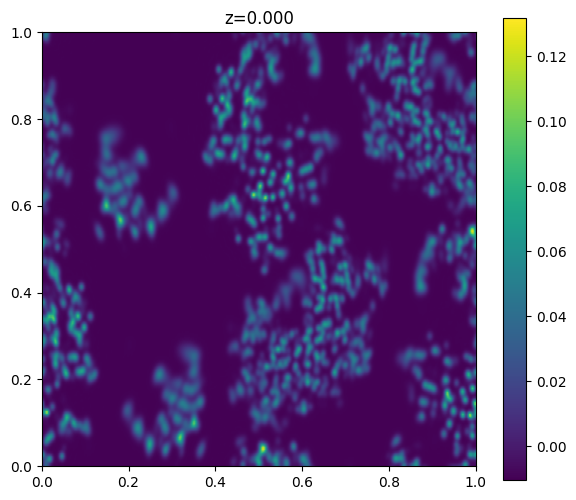

In [121]:
# _=slice_3d(dog_filter_real+np.tile(mask_ball,(2,2,2))*np.mean(np.abs(dog_filter_real)))
# _=slice_3d(rho_delta_xtr+mask_ball*np.mean(np.abs(rho_delta_xtr))*2)


# ds_dark = rs.read_mtz(dataloc_dark)
# ds_dark["sf_dark"] = ds_comb.to_structurefactor(dark_f, dark_phi)
# f_dark = ds_dark.to_reciprocal_grid( "sf_dark")
# density_dark = np.real(np.fft.ifftn(f_dark))


density_darkT
_=slice_3d(density_darkT+mask_hand_picked*np.mean(np.abs(density_darkT))*2)

interactive(children=(IntSlider(value=90, description='f0', max=179), Output()), _dom_classes=('widget-interac…

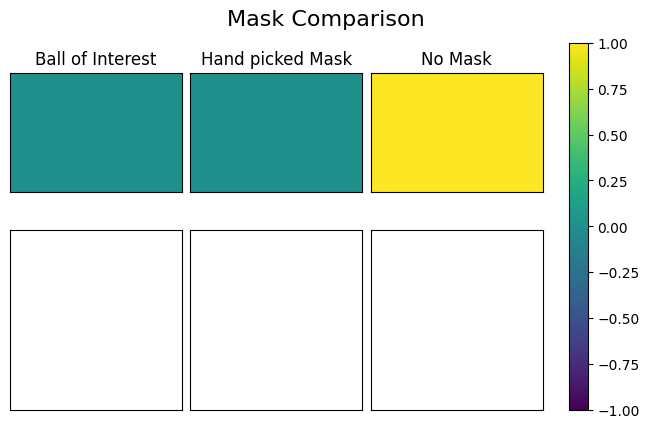

In [122]:
# panels_3d([dog_filter_real, dog_filter_xtr], title="DoG Filter Comparison")
# masks = [mask_dog_real, mask_dog_xtr, mask_truth, mask_ball, mask_hand_picked, np.ones_like(mask_ball)]
from output_eval import panels_3d
mask_names = [
    "dog_exp",
    "dog_dep",
    "pseudo-z",
    "ball",
    "handpicked",
    "nomask",
    ]
titles_mask = {
    "dog_exp":           "DoG (Measurement)", 
    "dog_dep":           "DoG (PDB deposited)",  
    "pseudo-z":          "largest and smallest values \n(0.01%) (PDB deposited)",
    "ball":               "Ball of Interest",
    "handpicked":         "Hand picked Mask",
    "nomask":         "No Mask",
}

masks = {}

sesh_name = "ball"
if sesh_name in mask_names:
    mask_ball = ccp4_to_mask(mask_loc_sphere, rho_dark.shape)
    masks[sesh_name] = mask_ball

sesh_name = "handpicked"
if sesh_name in mask_names:
    mask_hand_picked = ccp4_to_mask(mask_loc_handcraft, rho_dark.shape)
    masks[sesh_name] = mask_hand_picked

sesh_name = "nomask"
if sesh_name in mask_names:
    masks[sesh_name] = np.ones(rho_dark.shape,bool)

axtitles = [titles_mask[key] for key in masks.keys()]
_ =panels_3d(list(masks.values()), 
             title="Mask Comparison", 
             axtitles=axtitles, 
             figkwargs={'nrows':2,"ncols":3},
             imkwargs={'vmin':-1,'vmax':1}
             )


In [ ]:
# print([masks.keys()])
# _ = slice_3d(masks['dog_exp']+masks['handpicked'])
# _ = slice_3d(masks['dog_dep']+masks['handpicked'], imkwargs={'vmax':2})

# Occupancy determination attempts

In [ ]:
alphas = np.linspace(0.04,.99,15)
from occupancy import make_f_xtr
f_xtrs =  make_f_xtr(alphas, f_dark, f_light, f_angle,version=1)

In [ ]:
# slice_3d(dens_xtrs[-1])

In [85]:
density_deltaT = rho_dark 
rho_off = np.max(density_deltaT)/10
print(rho_off)
for mask in masks.values():
    # slice_3d(mask*rho_off + density_deltaT)
    pass


367696.70774391334


In [92]:
dens_xtrs = [k2real(f_xtr) for f_xtr in f_xtrs]
dens_xtrs[0].shape

(90, 150, 216)

## Negative Sum Explosion

In [ ]:
from occupancy import negsum_explode
from plotting3d import *
neg_sums = []
%matplotlib widget
for mask in masks.values():
    # slice_3d(mask*rho_dark)
    neg_sum = negsum_explode(dens_xtrs, np.array(mask,bool) )
    neg_sums.append(neg_sum)

n_largest = 3
alpha_invs = 2/alphas

In [20]:
from meteor import rsmap

In [ ]:
from plotting3d import add_fit
n_largest = 3
alpha_invs = 2/alphas
fig, axs = plt.subplots(3,2, figsize=(10,10),tight_layout=True)
for ii,neg_sum in enumerate(neg_sums):
    ax = axs.flat[ii]
    if n_largest:
        add_fit(neg_sum, alpha_invs, n_largest, ax=ax)

    ax.plot(alpha_invs, neg_sum * -1, "x")  # label="Datapoint")
    ax.set_title(titles_mask[mask_names[ii]])
    ax.legend()
    ax.set_xlabel("Inverse Occupancy")
    ax.set_ylabel(r"$\sum$ $|$neg. density$|$")
    ax.set_xlim(0,25)
# plt.ylim(0,300)
# plt.title(title)

## Histogram Method

### Histogram different masks

In [34]:
from plotting3d import val_distributions
config = {"alpha": "?", "zoom_in":False}
%matplotlib inline
density_dark = rho_dark
dark_min = np.min(rho_dark)
dark_max = np.max(rho_dark)
offset = (dark_max-dark_min)*0.1
bins = np.linspace(dark_min-offset, dark_max-offset, 150)

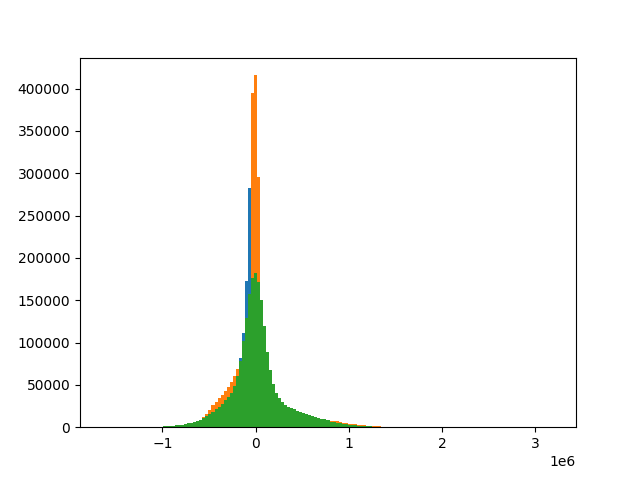

In [58]:
%matplotlib widget
plt.figure()
mask_values = ~np.logical_and(rho_dark>2e5,rho_dark<5e5)
mask_values = ~np.logical_and(rho_dark>-1.8e5,rho_dark<-5.20e4)
_ = plt.hist(rho_dark.flatten(),bins)
_ = plt.hist(rho_dark[mask_values],bins, )
_ = plt.hist(dens_xtrs[7][mask_values],bins, )
plt.show()

# _ = slice_3d(delta_rho+mask_balls)

In [101]:
from photolyase import get_hists, plot_hists
for ii, mask in enumerate(masks.values()):
    mask = np.logical_and(mask, mask_values)
    dhists, lhists, wdists, bin_centers = get_hists(dens_xtrs, rho_dark, mask, bins)
    fig,ax1 = plot_hists(dhists, lhists, wdists, bin_centers, alphas)
    fig.suptitle(axtitles[ii])
    fig, ax2 = plt.subplots() 
    fig.suptitle(axtitles[ii])
    ax2.plot(alphas, wdists)
    ax2.set_yscale('log')
    plt.show()
    break
    # combine_axes_equal(ax1, ax2)
    

IndexError: boolean index did not match indexed array along dimension 0; dimension is 180 but corresponding boolean dimension is 90

In [57]:
_ = plt.hist(dens_xtrs[0][mask])

### Histogram on phased result

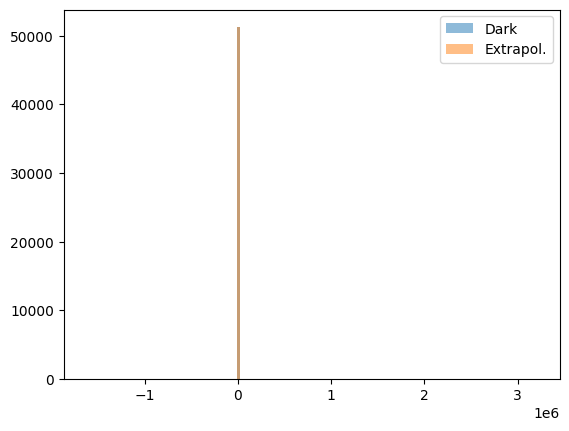

In [100]:
wassser_dist, bin_centers, hist_dark, hist_light = val_distributions3(density_darkT,density_lightT,mask_hand_picked, bins=bins,details=True)
barwidth = np.diff(bin_centers)[0]
%matplotlib inline
plt.figure()
plt.bar(bin_centers, hist_dark,width=barwidth, alpha=0.5, label="Dark")
plt.bar(bin_centers, hist_light,width=barwidth, alpha=0.5, label="Extrapol.")
plt.legend()
plt.show()

NameError: name 'f_xtrs_prime' is not defined

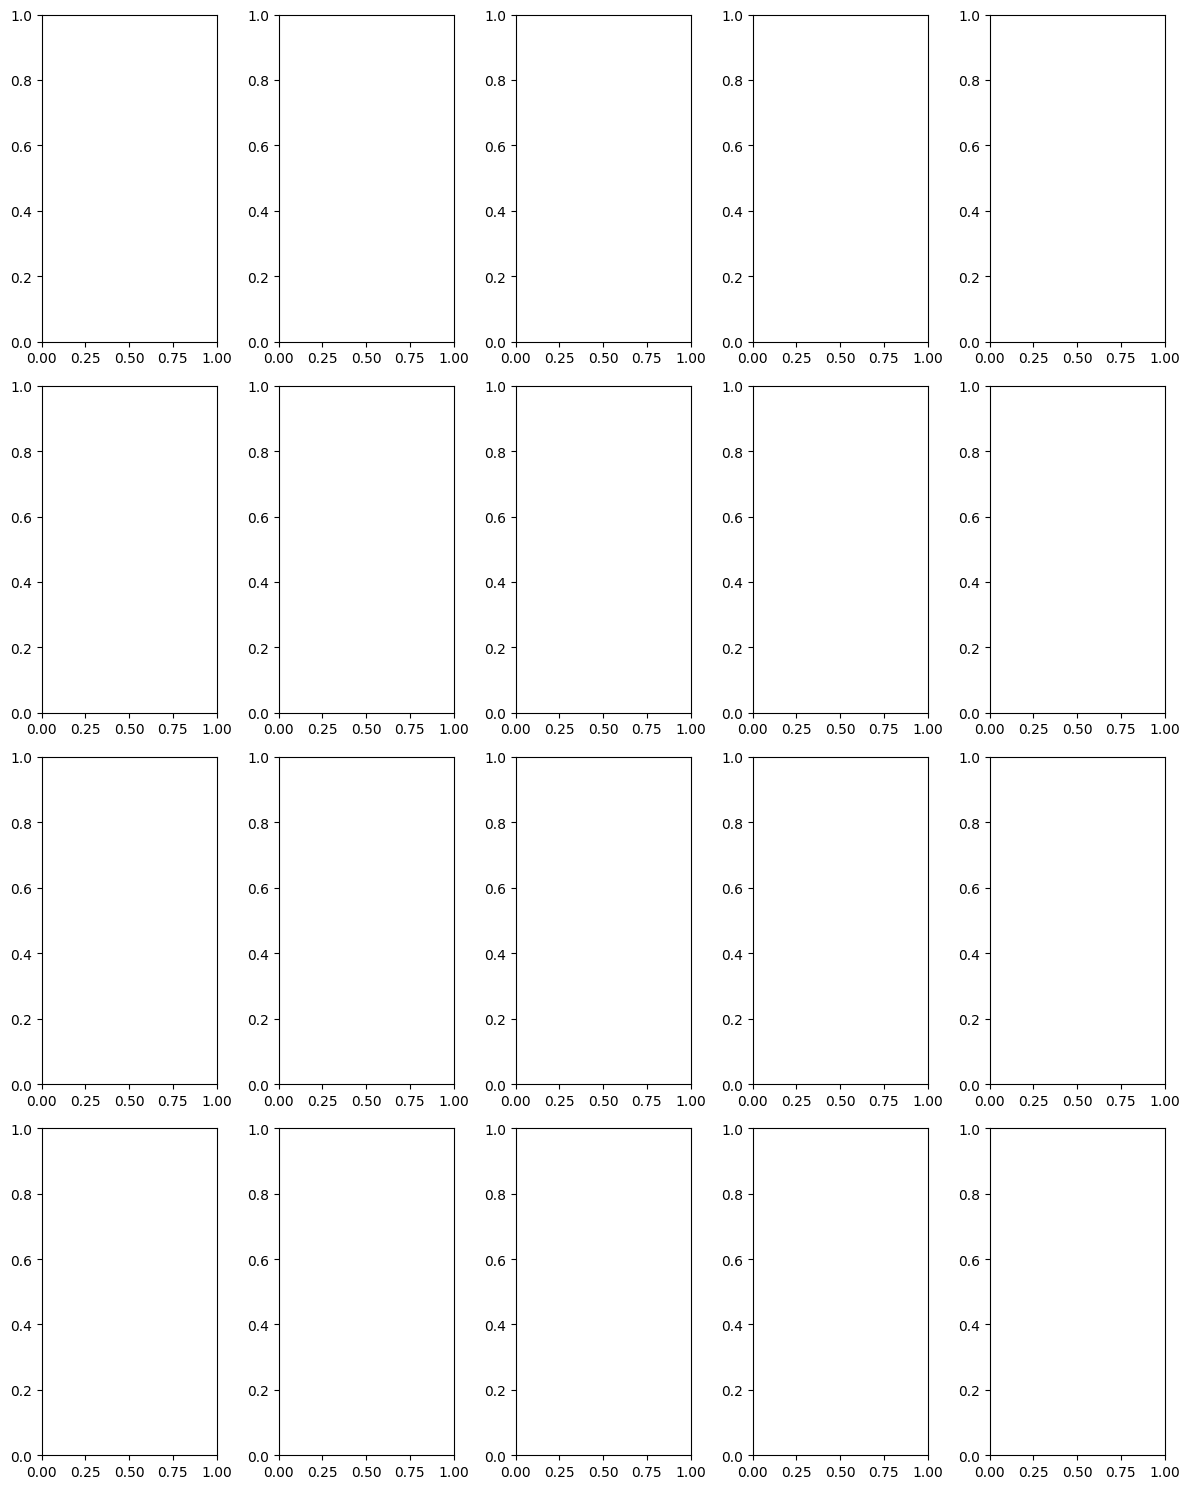

In [28]:
from plotting3d import val_distributions
config = {"alpha": "?", "zoom_in":False}
%matplotlib inline
# plt.figure()
density_dark = rho_dark
# dmin = np.min(density_dark)
# dmax = np.max(density_dark)
bins = np.arange(-.5, .5, 0.005)
bins = np.arange(-.1, .2, 0.005)

wdists = []
fig, axs = plt.subplots(4,5, figsize=(12,15),tight_layout=True)
for ii,(alpha_xtr, f_xtr) in enumerate(zip(alphas, f_xtrs_prime)):
    config["alpha_xtr"] = np.round(alpha_xtr,4)
    dens_xtr = np.real(np.fft.ifftn(f_xtr))
    wasser_dist = val_distributions2(
    rho_dark_prime,
        dens_xtr,
        mask_hand_picked,
        # ~np.isnan(mask_truth),
        bins,
        config,
        ax = axs.flat[ii]
    )
    wdists.append(wasser_dist)

In [ ]:
plt.figure()
plt.plot(alphas,wdists, "x")
plt.yscale("log")
plt.xlabel('Extrapolated Histogram')
plt.ylabel('Wasserstein Distance of Histograms')
plt.show()

# Exporting Data to coot

In [ ]:
alphas_show = np.array([0.08, 0.16, 0.4, 0.55])
f_xtrs_show =  make_f_xtr(alphas_show, f_dark, f_light, f_angle,version=1)
rho_xtrs = np.array([np.real(np.fft.fftn(fxtr))for fxtr in f_xtrs_show])

rho_xtrs.shape

In [ ]:
title_extrapolated = [f"manual_xtr_PL30_{(alph*100):.0f}.mtz" for alph in alphas_show]
title_extrapolated

In [ ]:
from meteor import rsmap
%matplotlib widget
def write_mtz(data_array, fname, rsdf, hs_limit):
    print('did you check orientation')
    mapobj = rsmap.Map.from_3d_numpy_map(data_array, 
                                         spacegroup=rsdf.spacegroup,
                                         cell =rsdf.cell, 
                                         high_resolution_limit=hs_limit)
    mapobj.write_mtz(fname)
    
# def write_mtz(datafile, name, rsdf, hs_limit):
#     mapobj = rsmap.Map.from_3d_numpy_map(np.fft.fftshift(datafile), spacegroup=19, cell =ds_comb.cell, high_resolution_limit=1.2)
#     mapobj.write_mtz(name)
    
# def write_mtz(datafile, name):
#     fg = gemmi.FloatGrid(*datafile.shape)
#     fg.spacegroup = ds_comb.spacegroup
#     fg.set_unit_cell(ds_comb.cell)
#     np.array(fg, copy=False)[:] = datafile
#     print(type(fg))
#     ccp4 = gemmi.Ccp4Map()
#     ccp4.grid = fg
#     # ccp4.update_header()
#     ccp4.write_ccp4_map(name)


    
for title, rho_xtr in zip(title_extrapolated,rho_xtrs,):
    write_mtz(rho_xtr, title,ds_light,hs_limit) 

In [ ]:
# panels_3d([
#     rho_xtrs[0],rho_xtrs[1],
#     rho_xtrs[2],rho_xtrs[3],
#            rho_dark, rho_light], 
#           axtitles=['16%', "40%", "dark","light"],
#           imkwargs={'vmin':np.min(rho_dark),'vmax':np.max(rho_dark)},
#           figkwargs={'nrows':2,'ncols':2})
panels_3d([rho_xtrs[1],rho_xtrs[2],rho_dark, rho_light], 
          axtitles=['16%', "40%", "dark","light"],
          imkwargs={'vmin':np.min(rho_dark),'vmax':np.max(rho_dark)},
          figkwargs={'nrows':2,'ncols':2})

In [ ]:
write_mtz(rho_dark, "rho_dark_again.mtz",ds_light,1.2) 


In [ ]:
# Cemetary

In [ ]:
f_delta = ds_comb.to_reciprocal_grid( "sf_delta")
f_light = ds_comb.to_reciprocal_grid( "sf_light")
f_dark[np.isnan(f_dark)]=0
f_light[np.isnan(f_light)]=0
print(f_dark[0,0,0])

from occupancy import make_f_xtr
f_angle = np.angle(f_dark)
# f_light[0,0,0] = -dmin*2


In [ ]:
f_light[np.isnan(f_light)]=0
f_dark[np.isnan(f_dark)]=0
print(f_dark[0,0,0])


In [ ]:
rho_dark =( np.fft.ifftn(f_dark))
dmin = np.min(rho_dark)
print("minimum")
print(dmin)
dmin = np.min(rho_dark-dmin)
dmin = np.min(rho_dark)
print(dmin)
f_dark_prime= np.fft.fftn(rho_dark-dmin)

# f_dark_prime-f_dark
print(np.sum((np.abs(f_dark_prime-f_dark))>1))
print(np.max(np.abs(f_dark_prime-f_dark)))
print(np.unravel_index(np.argmax(np.abs(f_dark_prime-f_dark)), f_dark.shape))
print(f_dark[0,0,0])
print(f_dark_prime[0,0,0])
# slice_3d()

# f_dark.size, 


In [ ]:
dmin = np.min(rho_dark)

f_dark_prime= f_dark.copy()
f_light_prime= f_light.copy()
f_dark_prime[0,0,0] =  -rho_dark.size*dmin
f_light_prime[0,0,0] =  -rho_dark.size*dmin

f_xtrs_prime =  make_f_xtr(alphas, f_dark_prime, f_light_prime, f_angle,version=1)
rho_dark_prime = np.fft.ifftn(f_dark_prime).real

In [ ]:

arr = np.array(ds_dark.get_hkls())
np.max(arr, axis=0)

In [ ]:

dark_f="F-obs-filtered"
dark_phi="PHIF-model"
# ds_light = "PHIF-model"
light_f = "FMEAN"

ds_dark["sf_dark"] = ds_dark.to_structurefactor(dark_f, dark_phi)
ds_light["sf_light"] = ds_light.to_structurefactor("F", dark_phi)

f_dark = ds_comb.to_reciprocal_grid( "sf_dark")
f_light = ds_comb.to_reciprocal_grid( "sf_light")

f_dark[np.isnan(f_dark)]=0
f_light[np.isnan(f_light)]=0
rho_true_light = np.fft.ifftn(f_light)
rho_true_dark = np.fft.ifftn(f_dark)
write_mtz(rho_true_dark,"rho_true_dark_PL30.mtz")
write_mtz(rho_true_light,"rho_true_light_PL30.mtz")

In [ ]:
 plt.close('all')

In [ ]:
write_mtz(dog_filter_real, "dog_filter_real.mtz") 
write_mtz(dog_filter_xtr, "dog_filter_xtr.mtz") 


In [ ]:
write_mtz(mask_dog_real*0.1, "mask_dog_real.mtz") 
write_mtz(mask_dog_xtr*0.1, "mask_dog_xtr.mtz") 
